Applying Tversky transformations to environmental audio

In [1]:
# imports

import torch
from torch.utils.data import DataLoader
from torchvision.transforms import PILToTensor
import math

import torch.nn as nn

import torch.nn.functional as F

from buowset_extractor import buowset_extractor

from pyha_analyzer.preprocessors import MelSpectrogramPreprocessors
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt

In [3]:
config = {
    "learning_rate": 10e-1,
    "learning_rate_decay": 0.001,
    "device": 'cuda',
    "seed": 1
}

In [4]:
torch.manual_seed(config["seed"])

In [ ]:
# from datasets import load_dataset

# mnist_dataset = load_dataset("mnist")

# train = mnist_dataset["train"]
# test = mnist_dataset["test"]

# def transform(batch):
#   t = PILToTensor()
#   batch['image'] = [t(img).float() for img in batch['image']]
#   batch['label'] = F.one_hot(torch.tensor(batch['label']), num_classes=10)
  
#   return batch

# train.set_transform(transform)
# test.set_transform(transform)

In [7]:
# simplest implementation

alpha = 0.1
beta = 0.1
theta = 0.1
phi = torch.mul
substract = True
batch_size = (10,)
feature_count = (10,)
feature_shape = (1, 28, 28)
class_count = (10,)

batch = torch.rand(batch_size + feature_shape)

f = torch.rand(feature_count + feature_shape)
pi = torch.rand(class_count + feature_shape)


output = []
for a in batch:
    batch_output = []
    for p in pi:
        a_f = torch.sum(a * f, (-1, -2, -3))
        p_f = torch.sum(p * f, (-1, -2, -3))

        val = phi(a_f, p_f)

        mask = (torch.minimum(a_f, p_f) <= 0).int()

        intersection = theta * (val * mask).sum()

        if substract:
            alpha_difference = -alpha * (a_f * ((a_f > 0) | (p_f <= 0)).int()).sum()
            beta_difference = -beta * (p_f * ((p_f > 0) | (a_f <= 0)).int()).sum()
        else:
            alpha_difference = -alpha * ((a_f - p_f) * ((a_f > 0) | (p_f > 0) | (a_f > p_f)).int()).sum()
            beta_difference = -beta * ((p_f - a_f) * ((p_f > 0) | (a_f > 0) | (p_f > a_f)).int()).sum()
        
        batch_output.append(float(intersection + alpha_difference + beta_difference))
    output.append(batch_output)
output1 = torch.tensor(output)
# print(output1)

def Tversky():
    print(batch.unsqueeze(1).shape, f.unsqueeze(2).shape)
    
    a_f = batch.unsqueeze(1) * f.unsqueeze(2)
    p_f = torch.sum(p * f, (-1, -2, -3))
    
    print(a_f.shape)

    val = phi(a_f, p_f)

    mask = (torch.minimum(a_f, p_f) <= 0).int()

    intersection = theta * (val * mask).sum()

    if substract:
        alpha_difference = -alpha * (a_f * ((a_f > 0) | (p_f <= 0)).int()).sum()
        beta_difference = -beta * (p_f * ((p_f > 0) | (a_f <= 0)).int()).sum()
    else:
        alpha_difference = -alpha * ((a_f - p_f) * ((a_f > 0) | (p_f > 0) | (a_f > p_f)).int()).sum()
        beta_difference = -beta * ((p_f - a_f) * ((p_f > 0) | (a_f > 0) | (p_f > a_f)).int()).sum()
    
    return intersection + alpha_difference + beta_difference
print(Tversky())

torch.Size([10, 1, 1, 28, 28]) torch.Size([10, 1, 1, 28, 28])
torch.Size([10, 1, 1, 28, 28])


RuntimeError: The size of tensor a (28) must match the size of tensor b (10) at non-singleton dimension 4

In [ ]:
class Tversky(nn.Module):
    """
    Similar to a fully-connected layer, but computes Tversky similarity instead
    """
    def __init__(
        self,
        num_classes: int,
        feature_shape: tuple,
        num_features: int,
        feature_bank=None,
        phi=torch.mul,
        substract=True,
        device=None,
        dtype=None
    ) -> None:
        factory_kwargs = {"device": device, "dtype": dtype}
        super().__init__()
        
        self.feature_shape = feature_shape
        
        self.phi = phi
        self.substract = substract
        
        if feature_bank is None:
            self.feature_bank = nn.Parameter(
                torch.empty((num_features) + feature_shape, **factory_kwargs)
            )
        else:
            self.feature_bank = feature_bank
            
        self.prototypes = nn.Parameter(
                torch.empty( (num_classes) + feature_shape, **factory_kwargs)
            )
            
        self.alpha = nn.Parameter(torch.empty(1))
        self.beta = nn.Parameter(torch.empty(1))
        self.theta = nn.Parameter(torch.empty(1))

        self.reset_parameters()
        
    def reset_parameters(self) -> None:
        nn.init.uniform_(self.feature_bank)
        nn.init.uniform_(self.prototypes)
        nn.init.normal_(self.alpha)
        nn.init.normal_(self.beta)
        nn.init.normal_(self.theta)
    
    @staticmethod
    def S(self, a, b):
        f = self.feature_bank
        
        b_f = (b.mT @ f.mT).T.unsqueeze(0)
        
        a_f = (a @ f.mT).unsqueeze(2)
        
        val = self.phi(a_f, b_f)
        
        mask = (torch.minimum(a_f, b_f) <= 0).int()
        
        intersection = self.theta * (val * mask).sum(dim=1)
        
        if self.substract:
            alpha_difference = -self.alpha * (a_f * ((a_f > 0) | (b_f <= 0)).int()).sum(dim=1)
            beta_difference = -self.beta * (b_f * ((b_f > 0) | (a_f <= 0)).int()).sum(dim=1)
        else:
            alpha_difference = -self.alpha * ((a_f - b_f) * ((a_f > 0) | (b_f > 0) | (a_f > b_f)).int()).sum(dim=1)
            beta_difference = -self.beta * ((b_f - a_f) * ((b_f > 0) | (a_f > 0) | (b_f > a_f)).int()).sum(dim=1)
        
        return intersection + alpha_difference + beta_difference
        
    def forward(self, input: torch.Tensor):
        return self.S(self, input, self.prototypes)  


tversky = Tversky(100, 10)

A = torch.rand(8, 100)

In [ ]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
    nn.Softmax(dim=-1)
).to(config['device'])

In [23]:
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0, lr=config["learning_rate"], betas=(0.8, 0.999))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda epoch : (1-config["learning_rate_decay"])**epoch)
metric = torch.nn.CrossEntropyLoss()
train_loader = DataLoader(mnist_dataset['train'], batch_size=8, num_workers=8, shuffle=True, pin_memory=True, pin_memory_device=config['device'])

In [27]:
step, loss = 0, []

correct, total = 0, 0

for epoch in range(5):
    for data in tqdm(train_loader, desc=str(epoch), leave=False):
        img = data['image']

        optimizer.zero_grad()
        x = img.to(config["device"])
        
        pred = model(x)
        label = data['label'].to(config["device"], torch.float)
        
        score = metric(pred, label)
        
        print(pred)
        
        score.backward()
        optimizer.step()
        
        loss.append(score.item())
        
        
        if step % 500 == 0:
            with torch.no_grad():
                print(np.mean(loss[-100:-1]))
            
        step += 1

0:   0%|          | 0/7500 [00:00<?, ?it/s]

tensor([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
nan
tensor([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.,

/home/a.jajodia.229/acoustic/anu_experiments_acoustic_species/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/a.jajodia.229/acoustic/anu_experiments_acoustic_species/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


tensor([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
tensor([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0.,

KeyboardInterrupt: 

TypeError: plot() got an unexpected keyword argument 'x'

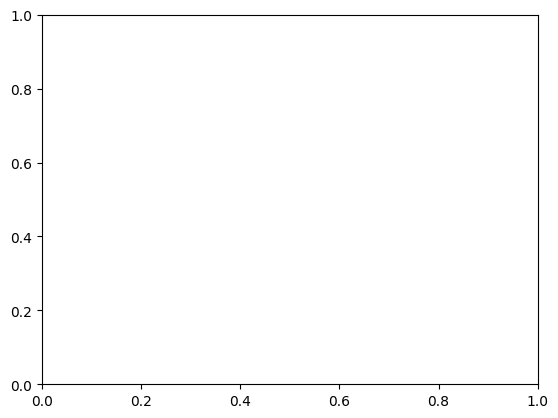

In [ ]:
import seaborn as sns

plt.plot(x=torch.arange(len(loss)), y=loss)